# Importing Libraries

In [30]:
# Importing Libraries
import pandas as pd
import numpy as np
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [31]:
print(sklearn.__version__)  # This will print the version of scikit-learn installed

1.5.1


In [32]:
# Define the file path
path = r'C:\Users\rbhte\OneDrive\monami\data_immersion\Achievement 6'

# Correctly reading the pickle file
df_rev = pd.read_pickle(os.path.join(path, 'Data', 'Prepared Data', 'df_revised.pkl'))

In [33]:
df_rev = df_rev.drop(columns=['Positive affect', 'Negative affect', '_merge'])

In [34]:
df_rev.columns

Index(['Country name', 'year', 'Life Ladder', 'Log GDP per capita',
       'Social support', 'Healthy life expectancy at birth',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption', 'Happiness Score', 'z_score',
       'Happiness Category', 'Country Code', 'IncomeGroup'],
      dtype='object')

# Clean the Data

In [37]:
# Check if missing values are there
df_rev.isnull().sum()

Country name                        0
year                                0
Life Ladder                         0
Log GDP per capita                  0
Social support                      0
Healthy life expectancy at birth    0
Freedom to make life choices        0
Generosity                          0
Perceptions of corruption           0
Happiness Score                     0
z_score                             0
Happiness Category                  0
Country Code                        0
IncomeGroup                         0
dtype: int64

In [38]:
# Check if duplicates are there
df_rev.duplicated().sum()

0

In [41]:
df_rev['Happiness Category'].unique()  # Unique values for 'Happiness Category'

['Low Happiness', 'Medium Happiness', 'High Happiness']
Categories (3, object): ['Low Happiness' < 'Medium Happiness' < 'High Happiness']

In [42]:
df_rev['IncomeGroup'].unique()         # Unique values for 'IncomeGroup'

array(['Low income', 'Upper middle income', 'Lower middle income',
       'High income'], dtype=object)

In [59]:
# Convert categorical columns (Happiness Category, IncomeGroup) to categorical types
df_rev['Happiness Category'] = df_rev['Happiness Category'].astype('category')
df_rev['IncomeGroup'] = df_rev['IncomeGroup'].astype('category')

# Verify the change
df_rev.dtypes

Country name                          object
year                                   int64
Life Ladder                          float64
Log GDP per capita                   float64
Social support                       float64
Healthy life expectancy at birth     float64
Freedom to make life choices         float64
Generosity                           float64
Perceptions of corruption            float64
Happiness Score                      float64
z_score                              float64
Happiness Category                  category
Country Code                          object
IncomeGroup                         category
dtype: object

In [45]:
# Check if Country Code follows the standard 3-letter format
df_rev['Country Code'].str.len().value_counts()

Country Code
3    2055
Name: count, dtype: int64

Now the data is clean and ready for further analysis.

# Creating a Scatter Plot

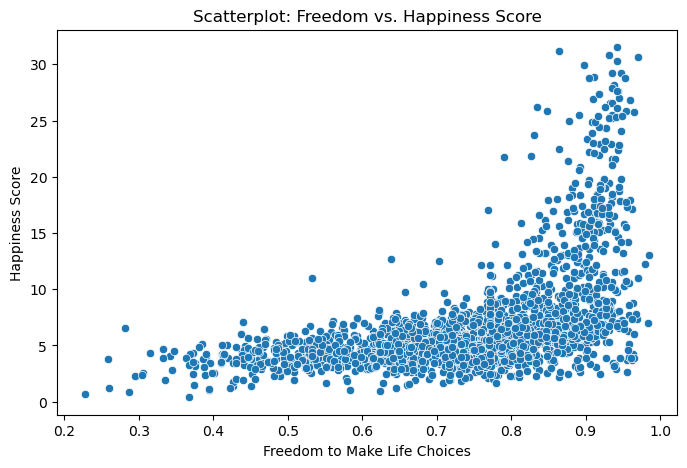

In [46]:
#Create a scatterplot to visualize the relationship between Freedom to make life choices (independent variable) and Happiness Score (dependent variable)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df_rev['Freedom to make life choices'], y=df_rev['Happiness Score'])
plt.xlabel("Freedom to Make Life Choices")
plt.ylabel("Happiness Score")
plt.title("Scatterplot: Freedom vs. Happiness Score")
plt.show()

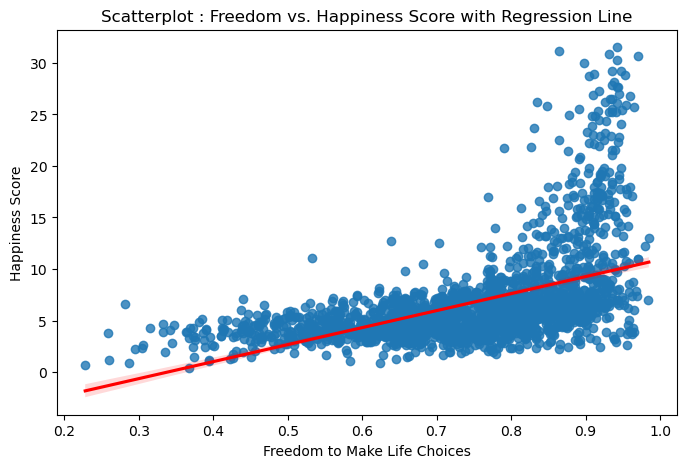

In [54]:
# Scatter plot with regression line
plt.figure(figsize=(8, 5))
sns.regplot(x=df_rev['Freedom to make life choices'], 
            y=df_rev['Happiness Score'], 
            scatter=True, 
            line_kws={"color": "red"})  # Regression line in red

# Labels and title
plt.xlabel("Freedom to Make Life Choices")
plt.ylabel("Happiness Score")
plt.title("Scatterplot : Freedom vs. Happiness Score with Regression Line")

# Define the save path
save_path = r'C:\Users\rbhte\OneDrive\monami\data_immersion\Achievement 6\Visualisations\freedom_vs_happiness.png'

# Save the plot
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

# Hypotheses Under Investigation

Freedom and Happiness

H₀: Perceived freedom to make life choices does not affect happiness scores.
H₁: Countries with higher freedom scores tend to have higher happiness scores.

# Extract Freedom to make life choices as X (independent variable) and Happiness Score as y (dependent variable), then reshape them into NumPy arrays.

In [49]:
# Define independent (X) and dependent (y) variables
X = df_rev['Freedom to make life choices'].values.reshape(-1, 1)  # Reshape to 2D array
y = df_rev['Happiness Score'].values.reshape(-1, 1)

# Split the data into two sets : a training set and a test set

In [50]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the sizes of the training and test sets
print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")

Training set size: 1644 rows
Test set size: 411 rows


We will use 80% of the data for training and 20% for testing.

# Run a linear regression on the data

We will fit a linear regression model to the training data and use it to make predictions on the test data.

In [51]:
from sklearn.linear_model import LinearRegression

# Initialize the model
model = LinearRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Print model coefficients
print(f"Intercept: {model.intercept_[0]}")
print(f"Coefficient: {model.coef_[0][0]}")

Intercept: -5.652982489611345
Coefficient: 16.578986045692382


# Create a plot that shows the regression line on the test set

We will visualize the regression line by plotting the actual Happiness Score against Freedom to make life choices for the test set

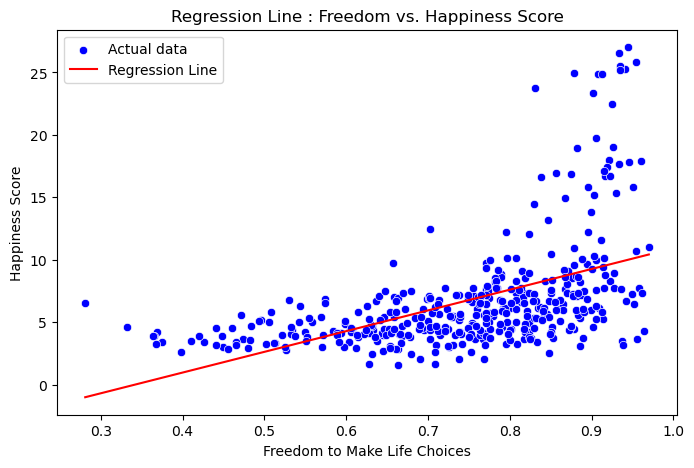

In [55]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_test.flatten(), y=y_test.flatten(), label="Actual data", color="blue")
sns.lineplot(x=X_test.flatten(), y=y_pred.flatten(), color="red", label="Regression Line")
plt.xlabel("Freedom to Make Life Choices")
plt.ylabel("Happiness Score")
plt.title("Regression Line : Freedom vs. Happiness Score")
plt.legend()

# Define the save path
save_path1 = r'C:\Users\rbhte\OneDrive\monami\data_immersion\Achievement 6\Visualisations\freedom_vs_happiness(test_set).png'

# Save the plot
plt.savefig(save_path1, dpi=300, bbox_inches='tight')
plt.show()

Interpretation :

The red line represents the regression model’s predictions, while the blue dots represent the actual test data points. As the points align closely with the red line, the model is a good fit, meaning the relationship is quite strong.

# Check the model performance statistics—MSE and R² score

We will evaluate the model’s performance using the Mean Squared Error (MSE) and R² score

In [56]:
from sklearn.metrics import mean_squared_error, r2_score

# Calculate MSE and R² score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print the performance metrics
print(f"Mean Squared Error (MSE): {mse}")
print(f"R² Score: {r2}")

Mean Squared Error (MSE): 15.14584295088026
R² Score: 0.2466345692759444


Interpretation :

MSE (Mean Squared Error): 15.15 is relatively high, meaning the model’s predictions deviate significantly from the actual happiness scores. A lower MSE would indicate better accuracy.
R² Score: 0.247 suggests that only about 24.7% of the variation in Happiness Score is explained by Freedom to make life choices. This means the model has limited explanatory power and other variables (such as GDP, social support, or corruption perceptions) likely play a much bigger role in determining happiness.

# Compare the predicted y values with the actual y values in a dataframe

We will create a DataFrame to compare actual vs. predicted values

In [58]:
# Create a dataframe for comparison
comparison_df = pd.DataFrame({'Actual Happiness Score': y_test.flatten(),
                              'Predicted Happiness Score': y_pred.flatten()})

# Display first few rows
comparison_df.head()

,Actual Happiness Score,Predicted Happiness Score
0,6.172651,9.417316
1,6.077025,6.333624
2,4.318857,4.029145
3,16.905459,8.853630
4,2.580184,8.405998


The table above allows us to compare the actual Happiness Score with the model’s predicted values. A small difference means a better prediction, but in this case, some predictions have large errors, indicating the model may not be fitting the data well.

Bias in the data can affect the accuracy of our predictions and lead to incorrect conclusions. Although the model works for some cases, the large errors in predictions suggest that there might be issues with the data or the model itself. There could be several sources of bias, such as sampling bias (where certain countries or income groups are overrepresented), feature selection bias (missing important factors that influence happiness), reporting bias (cultural differences in self-reported happiness) and model bias (where a linear model doesn’t capture all the complexities).

By addressing these biases, I believe we can improve the model’s accuracy and make it more reliable for real-world use.